In [1]:
import os
import ast
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models import resnet50


In [2]:
csv_path = "/kaggle/input/nh-chest-xrays-reduced-dataset/reduced_data.csv"
img_dir = "/kaggle/input/nh-chest-xrays-reduced-dataset/images/images"

df = pd.read_csv(csv_path)

# Converte string "['A', 'B']" para lista Python
df["Finding Labels"] = df["Finding Labels"].apply(ast.literal_eval)

all_labels = sorted(list({lab for sub in df["Finding Labels"] for lab in sub}))
mlb = MultiLabelBinarizer(classes=all_labels)
df["targets"] = mlb.fit_transform(df["Finding Labels"]).tolist()

num_classes = len(all_labels)
num_classes, all_labels

(15,
 ['Atelectasis',
  'Cardiomegaly',
  'Consolidation',
  'Edema',
  'Effusion',
  'Emphysema',
  'Fibrosis',
  'Hernia',
  'Infiltration',
  'Mass',
  'No Finding',
  'Nodule',
  'Pleural_Thickening',
  'Pneumonia',
  'Pneumothorax'])

In [3]:
'''Convolutional Block Attention Module (CBAM)
'''

import torch
import torch.nn as nn
from torch.nn.modules import pooling
from torch.nn.modules.flatten import Flatten



class Channel_Attention(nn.Module):
    '''Channel Attention in CBAM.
    '''

    def __init__(self, channel_in, reduction_ratio=16, pool_types=['avg', 'max']):
        '''Param init and architecture building.
        '''

        super(Channel_Attention, self).__init__()
        self.pool_types = pool_types

        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=channel_in, out_features=channel_in//reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=channel_in//reduction_ratio, out_features=channel_in)
        )


    def forward(self, x):
        b, c, h, w = x.size()
    
        # média global
        avg_pool = torch.mean(x, dim=(2, 3), keepdim=True)
    
        # máximo global (reduzindo um eixo por vez)
        max_pool, _ = torch.max(x, dim=2, keepdim=True)
        max_pool, _ = torch.max(max_pool, dim=3, keepdim=True)
    
        # flatten e passa pelo MLP
        avg_out = self.shared_mlp(avg_pool.view(b, c))
        max_out = self.shared_mlp(max_pool.view(b, c))
    
        out = avg_out + max_out
        scale = torch.sigmoid(out).view(b, c, 1, 1)
    
        return x * scale


class ChannelPool(nn.Module):
    '''Merge all the channels in a feature map into two separate channels where the first channel is produced by taking the max values from all channels, while the
       second one is produced by taking the mean from every channel.
    '''
    def forward(self, x):
        return torch.cat((torch.max(x, 1)[0].unsqueeze(1), torch.mean(x, 1).unsqueeze(1)), dim=1)


class Spatial_Attention(nn.Module):
    '''Spatial Attention in CBAM.
    '''

    def __init__(self, kernel_size=7):
        '''Spatial Attention Architecture.
        '''

        super(Spatial_Attention, self).__init__()

        self.compress = ChannelPool()
        self.spatial_attention = nn.Conv2d(in_channels=2, out_channels=1, kernel_size=kernel_size, stride=1, dilation=1, padding=(kernel_size-1)//2, bias=False)
            
       


    def forward(self, x):
        '''Forward Propagation.
        '''
        x_compress = self.compress(x)
        x_output = self.spatial_attention(x_compress)
        scaled = torch.sigmoid(x_output)
        return x * scaled


class CBAM(nn.Module):
    '''CBAM architecture.
    '''
    def __init__(self, channel_in, reduction_ratio=16, pool_types=['avg', 'max'], spatial=True):
        '''Param init and arch build.
        '''
        super(CBAM, self).__init__()
        self.spatial = spatial

        self.channel_attention = Channel_Attention(channel_in=channel_in, reduction_ratio=reduction_ratio, pool_types=pool_types)

        if self.spatial:
            self.spatial_attention = Spatial_Attention(kernel_size=7)


    def forward(self, x):
        '''Forward Propagation.
        '''
        x_out = self.channel_attention(x)
        if self.spatial:
            x_out = self.spatial_attention(x_out)

        return x_out

In [ ]:
from torchvision.models.resnet import Bottleneck

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.base = resnet50(weights="IMAGENET1K_V1")

        self.cbam3 = CBAM(channel_in=1024)
        self.cbam4 = CBAM(channel_in=2048)
        self.base.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        # Camadas originais até layer3
        x = self.base.conv1(x)
        x = self.base.bn1(x)
        x = self.base.relu(x)
        x = self.base.maxpool(x)

        x = self.base.layer1(x)
        x = self.base.layer2(x)
        x = self.base.layer3(x)
        x = self.cbam3(x)  # CBAM aqui
        x = self.base.layer4(x)
        x_conv = self.cbam4(x)  # salvar as features com atenção

        x = self.base.avgpool(x_conv)
        x = torch.flatten(x, 1)
        x = self.base.fc(x)
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
## SE O MODELO JA ESTIVER TREINADO
path_modelo = '/kaggle/input/nih-chest-xray-resnet50-cbam/pytorch/default/1/best_resnet50_cbam_nih.pth'

model = ResNet50_CBAM(num_classes=15)
model.load_state_dict(torch.load(path_modelo, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


ResNet50_CBAM(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [7]:
class NIHChestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.images = df["Image Index"].values
        self.targets = df["targets"].values
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        target = torch.tensor(self.targets[idx]).float()
        return img, target

In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [112]:
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)

train_dataset = NIHChestDataset(train_df, img_dir, transform=train_transforms)
val_dataset   = NIHChestDataset(val_df,   img_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

In [113]:
model = ResNet50_CBAM(num_classes=num_classes)
model = model.to(device)

In [114]:

import torch.optim as optim


criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3)

In [115]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [116]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            
            
            total_labels = 0 

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    
                    preds = torch.sigmoid(outputs) > 0.5
                    
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data.bool())
                total_labels += inputs.size(0) * labels.size(1)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / total_labels

            print(f"{phase} Loss: {epoch_loss:.4f} Acc (Global por label): {epoch_acc:.4f}")

            if phase == 'val':
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    save_path = "best_resnet50_cbam_nih.pth"
                    torch.save(model.state_dict(), save_path)

    print(f"\nTreinamento concluído! Melhor acurácia de validação: {best_acc:.4f}")

In [118]:
train_model(model, criterion, optimizer, scheduler, num_epochs=4)


Época 1/4
------------------------------
train Loss: 0.3733 Acc (Global por label): 0.8624
val Loss: 0.3278 Acc (Global por label): 0.8732

Época 2/4
------------------------------
train Loss: 0.3273 Acc (Global por label): 0.8707
val Loss: 0.3238 Acc (Global por label): 0.8724

Época 3/4
------------------------------
train Loss: 0.3126 Acc (Global por label): 0.8754
val Loss: 0.3139 Acc (Global por label): 0.8756

Época 4/4
------------------------------
train Loss: 0.3026 Acc (Global por label): 0.8776
val Loss: 0.3084 Acc (Global por label): 0.8758

Treinamento concluído! Melhor acurácia de validação: 0.8758


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr
from skimage.measure import label
def get_heatmap(model, model_name, explain_fn, img_tensor, target=None):
    if model_name == 'GradCAM' or model_name == 'RISE':
        base_heatmap = explain_fn(img_tensor)
    elif model_name == 'ScoreCAM':
        base_heatmap = explain_fn(img_tensor, target) 
    elif model_name == 'IG':
        output = model(img_tensor)
        pred_prob = F.softmax(output, dim=1)
        pred_class_idx = torch.argmax(pred_prob, dim=1).item()
        baseline = torch.zeros_like(img_tensor).to(img_tensor.device)
        base_heatmap = explain_fn(img_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    elif model_name == 'Grad+Score':
        base_heatmap = explain_fn(img_tensor)

    
    return base_heatmap

## FIDELITY
def deletion_test(model, img_tensor, heatmap, correct_class, max_steps=20, pixels_per_step = 5, deletion_value=0.0):
    model.eval()

    img = img_tensor.clone()
    C, H, W = img.shape[1], img.shape[2], img.shape[3]

    heat = heatmap.astype(np.float32)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8) # Norm

    flat = heat.flatten()
    num_pixels = len(flat)

    sorted_idx = np.argsort(-flat)  # Descending order

    confidences = []
    predictions = []

    broke = None
    for step in range(1, max_steps + 1):
        start = (step-1) * pixels_per_step
        end = min(step * pixels_per_step, num_pixels)
        idx_to_delete = sorted_idx[start:end]

        if len(idx_to_delete) == 0:
            break

        for idx in idx_to_delete:
            h = idx // W
            w = idx % W
            img[0, :, h, w] = deletion_value



        with torch.no_grad():
            logits = model(img)
            probs = torch.sigmoid(logits)[0]
            # labels com prob > 0.5
            predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
            if correct_class not in predicted and broke is None:
                broke = step
                return confidences, predictions, broke

    return confidences, predictions, broke

## ROBUSTNESS
def robustness_test(model, model_name, img_tensor, explain_fn, target=None, sigma=0.1, n_perturb=5):
    model.eval()

    base_heatmap = get_heatmap(model, model_name, explain_fn, img_tensor, target)
    
    base_flat = base_heatmap.flatten()

    correlations = []

    for _ in range(n_perturb):

        # Adiciona ruído gaussiano à imagem
        noise = torch.randn_like(img_tensor) * sigma
        noisy_img = img_tensor + noise

        noisy_heatmap = get_heatmap(model, model_name, explain_fn, noisy_img, target)

        noisy_flat = noisy_heatmap.flatten()


        if isinstance(base_flat, torch.Tensor):
            base_flat = base_flat.detach().cpu().numpy()
        else:
            base_flat = np.array(base_flat)

        if isinstance(noisy_flat, torch.Tensor):
            noisy_flat = noisy_flat.detach().cpu().numpy()
        else:
            noisy_flat = np.array(noisy_flat)
        r, _ = pearsonr(base_flat, noisy_flat)

        correlations.append(r)

    # Média das correlações
    return np.mean(correlations)



## SPARSITY AND SPATIAL COHERENCE
def calculate_gini_index(heatmap):
    h_flat = np.abs(heatmap.flatten())
    h_sorted = np.sort(h_flat)
    n = len(h_sorted)
    if n == 0 or np.sum(h_sorted) == 0: return 0.0
    cum_sum = np.cumsum(h_sorted)
    B = np.sum(cum_sum) / cum_sum[-1]
    gini = (n + 1 - 2 * B) / n
    return gini

def calculate_spatial_coherence(heatmap, threshold_percent=0.5):
    if np.max(heatmap) - np.min(heatmap) < 1e-7: return 1.0
    h_norm = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-7)
    threshold = threshold_percent * np.max(h_norm)
    binary_map = h_norm > threshold
    labeled_map, num_labels = label(binary_map, connectivity=2, background=0, return_num=True)
    if num_labels == 0: return 0.0
    total_energy = np.sum(h_norm[binary_map])
    if total_energy == 0: return 0.0
    max_cluster_energy = 0
    for i in range(1, num_labels + 1):
        cluster_mask = labeled_map == i
        cluster_energy = np.sum(h_norm[cluster_mask])
        if cluster_energy > max_cluster_energy:
            max_cluster_energy = cluster_energy
    return max_cluster_energy / total_energy


## INTRA-CLASS CONSISTENCY

def intraclass_consistency(lista_heatmaps):
    heatmaps_flat = np.array([h.flatten() for h in lista_heatmaps])
    matriz_corr = np.corrcoef(heatmaps_flat)
    indices_tri_sup = np.triu_indices_from(matriz_corr, k=1)
    correlacoes = matriz_corr[indices_tri_sup]
    score_consistencia = np.mean(correlacoes)
    return score_consistencia

In [9]:
image_paths = ['/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00022604_015.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00001250_006.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00030079_022.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00011237_066.png']

In [10]:
img_path = '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00011237_066.png'


raw_img = Image.open(img_path).convert("RGB")
input_tensor = val_transforms(raw_img).unsqueeze(0).to(next(model.parameters()).device)


model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.sigmoid(logits)[0]

# labels com prob > 0.5
predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
print(predicted)

['Infiltration']


In [ ]:
# Dicionário para armazenar as ativações
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Registra o hook na atenção espacial da última CBAM
model.cbam4.spatial_attention.register_forward_hook(get_activation('spatial_attn'))

Classe predita: 8


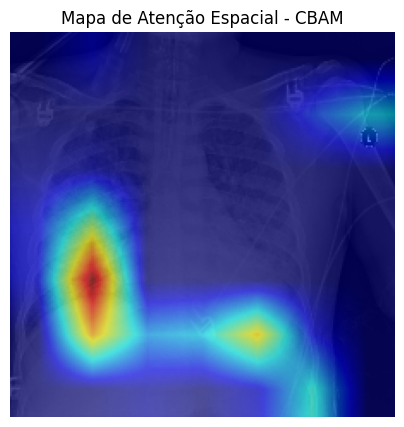

Classe predita: 8


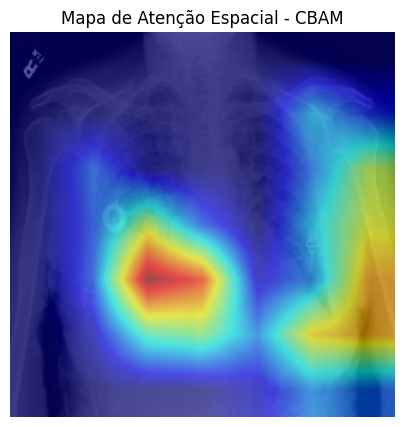

Classe predita: 8


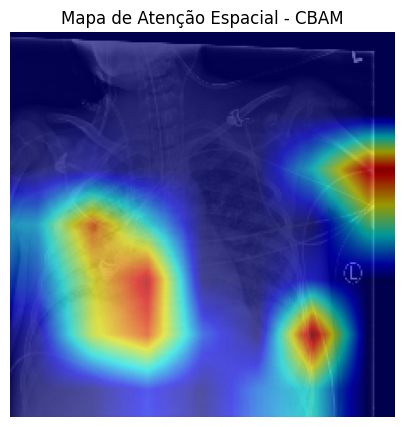

Classe predita: 8


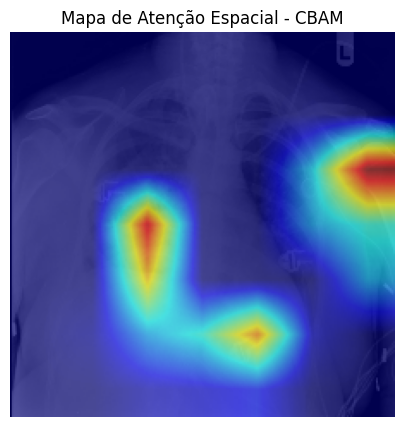

In [127]:
for img_path in image_paths:
    image = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    print(f"Classe predita: {pred_class}")

    
    attn_map = activation['spatial_attn'][0, 0].cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    attn_map_resized = cv2.resize(attn_map, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * attn_map_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)


    img_np = np.array(image)
    img_np = cv2.resize(img_np, (224, 224))
    superimposed = np.uint8(0.6 * heatmap + 0.4 * img_np)


    plt.figure(figsize=(5,5))
    plt.title("Mapa de Atenção Espacial - CBAM")
    plt.imshow(superimposed)
    plt.axis("off")
    plt.show()


In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        class_score = output[0, class_idx]
        class_score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1).squeeze()

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()
        cam = cam.cpu().numpy()
        
        cam = cv2.resize(cam, (224, 224))
        return cam

In [13]:
target_layer = model.cbam4

gradcam = GradCAM(model, target_layer)

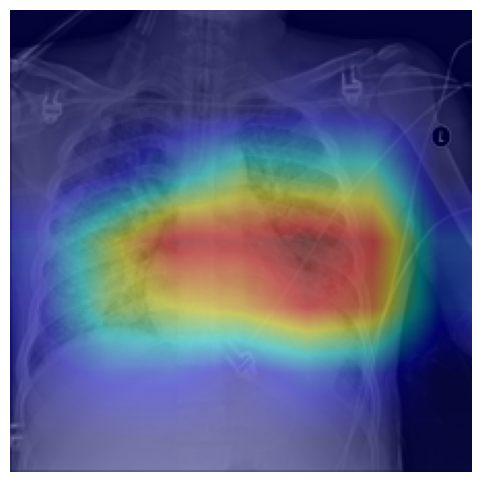

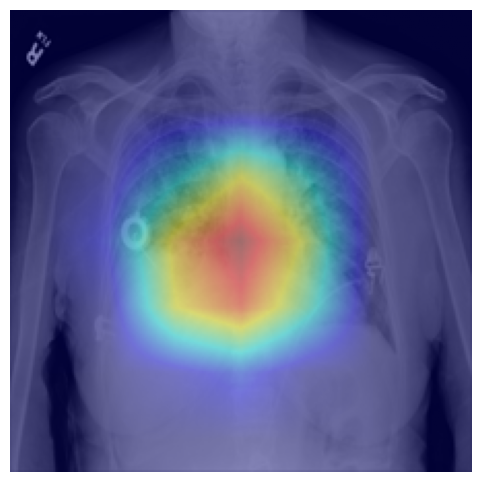

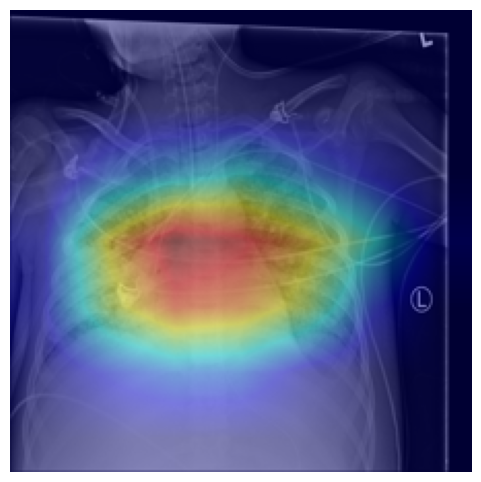

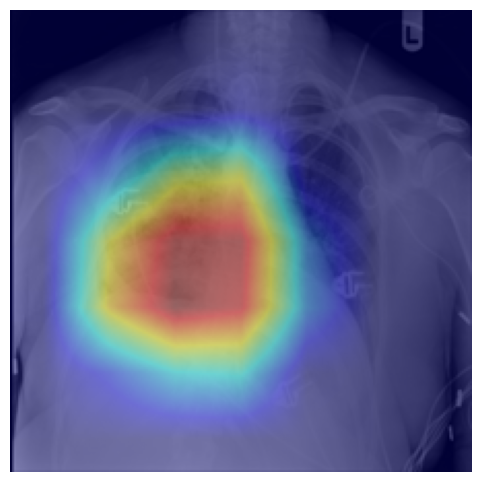

In [130]:
for img_path in image_paths:
    raw_img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(raw_img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    predicted
    
    cam = gradcam.generate(input_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    
    raw_np = np.array(raw_img.resize((224, 224))) / 255.0
    overlay = heatmap * 0.4 + raw_np * 0.6
    overlay = np.clip(overlay, 0, 1)
    
    # Salva e exibe
    #save_path = os.path.join(Config.OUTPUT_DIR, f"gradcam_{img_name}")
    #plt.imsave(save_path, overlay)
    #print(f"Grad-CAM salvo em: {save_path}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [133]:
broke_list = []
heatmaps = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    cam = gradcam.generate(input_tensor)
    if len(cam.shape) == 3:
        cam = cam[0]

    heatmap = cam
    heatmaps.append(heatmap)
    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration' , max_steps=3000)
    print(f"Broke at step: {broke}")
    broke_list.append(broke)


print("Broke_mean:", np.mean(broke_list))

Broke at step: 27
Broke at step: 1
Broke at step: 93
Broke at step: 18
Broke_mean: 34.75


In [134]:

robustness_scores = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)


    robustness_score = robustness_test(model, 'GradCAM', input_tensor, gradcam.generate)
    print(f"Robustness score: {robustness_score}")
    robustness_scores.append(robustness_score)

print(f"Average robustness score: {np.mean(robustness_scores)}")

Robustness score: 0.08559291064739227
Robustness score: 0.017442863434553146
Robustness score: 0.7444242238998413
Robustness score: 0.2377122938632965
Average robustness score: 0.2712930738925934


In [135]:

from skimage.measure import label

gini_list = []
coherence_list = []
for heatmap in heatmaps:
    grayscale_cam = heatmap
    gini_index = calculate_gini_index(grayscale_cam)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(grayscale_cam)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print(f"Average Gini Index: {np.mean(gini_list)}")
print(f"Average Spatial Coherence: {np.mean(coherence_list)}")

Gini Index: 0.6386840586759606
Spatial Coherence: 1.0
Gini Index: 0.7838261857324716
Spatial Coherence: 1.0
Gini Index: 0.6905895739185567
Spatial Coherence: 1.0
Gini Index: 0.7507387472658741
Spatial Coherence: 1.0
Average Gini Index: 0.7159596413982158
Average Spatial Coherence: 1.0


In [136]:
consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.8398668552902574


In [14]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.6 MB/s eta 0:00:00

In [15]:
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

100%|██████████| 128/128 [00:07<00:00, 18.22it/s]


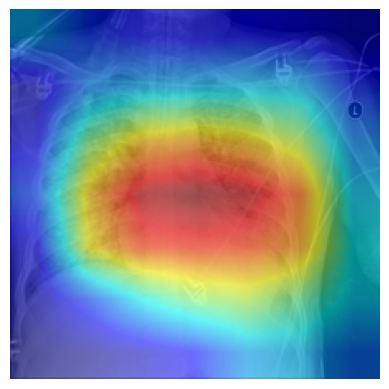

100%|██████████| 128/128 [00:07<00:00, 17.65it/s]


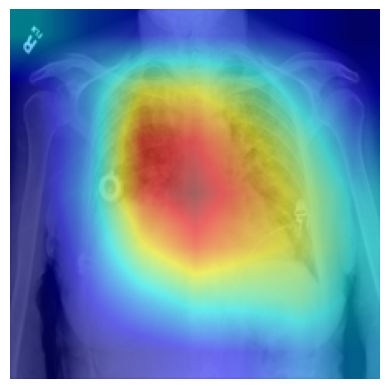

100%|██████████| 128/128 [00:07<00:00, 16.87it/s]


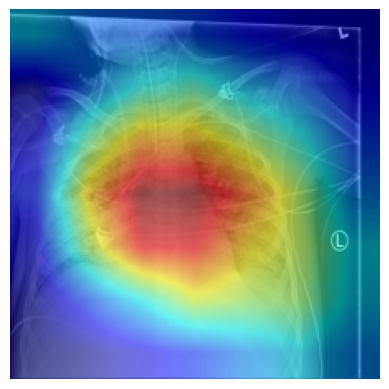

100%|██████████| 128/128 [00:07<00:00, 16.19it/s]


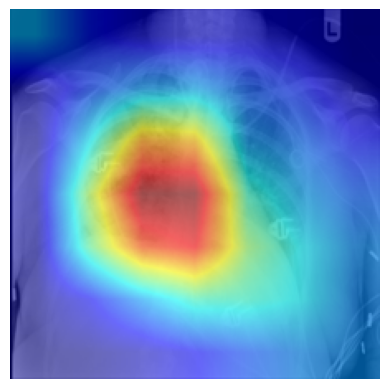

In [143]:
heatmaps_score = []
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    
    
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    target_layer = model.cbam4
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()
    heatmaps_score.append(grayscale_cam)
    
    rgb_img = np.array(img.resize((224, 224))) / 255.0
    vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.imshow(vis)
    plt.axis('off')
    plt.show()

In [144]:
broken_list = []
for image_path, heatmap in zip(image_paths, heatmaps_score):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    if len(grayscale_cam.shape) == 3:
        grayscale_cam = grayscale_cam[0]

    confidences, predictions, broken = deletion_test(model, input_tensor, grayscale_cam, 'Infiltration', max_steps=3000)
    if broken is not None:
        broken_list.append(broken)
    
    print(f"Broken at step: {broken}")

print(f"Average broken step: {np.mean(broken_list)}")



100%|██████████| 128/128 [00:07<00:00, 16.52it/s]


Broken at step: 93


100%|██████████| 128/128 [00:07<00:00, 16.19it/s]


Broken at step: 1


100%|██████████| 128/128 [00:08<00:00, 15.82it/s]


Broken at step: 162


100%|██████████| 128/128 [00:07<00:00, 16.35it/s]


Broken at step: 18
Average broken step: 68.5


In [145]:
robustness_scores = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0)
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]

    robustness_score = robustness_test(model, 'ScoreCAM', input_tensor, cam, targets)
    print(f"Robustness score: {robustness_score}")
    robustness_scores.append(robustness_score)

print(f"Average robustness score: {np.mean(robustness_scores)}")

100%|██████████| 128/128 [00:07<00:00, 16.50it/s]


Robustness score: 0.7434806823730469


100%|██████████| 128/128 [00:07<00:00, 17.33it/s]


Robustness score: 0.7864999175071716


100%|██████████| 128/128 [00:07<00:00, 16.63it/s]


Robustness score: 0.9182831048965454


100%|██████████| 128/128 [00:07<00:00, 17.17it/s]

Robustness score: 0.6099349856376648
Average robustness score: 0.7645496726036072


In [146]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_score:
    grayscale_cam = heatmap
    gini_index = calculate_gini_index(grayscale_cam)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(grayscale_cam)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print(f"Average Gini Index: {np.mean(gini_list)}")
print(f"Average Spatial Coherence: {np.mean(coherence_list)}")

Gini Index: 0.378180134053133
Spatial Coherence: 1.0
Gini Index: 0.3985185428541534
Spatial Coherence: 1.0
Gini Index: 0.36604456998864
Spatial Coherence: 1.0
Gini Index: 0.42771354986696825
Spatial Coherence: 1.0
Average Gini Index: 0.3926141991907236
Average Spatial Coherence: 1.0


In [147]:
consistency = intraclass_consistency(heatmaps_score)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.9224330611243662


In [16]:
class RISE(nn.Module):
    def __init__(self, model, input_size, gpu_batch=10):
        super(RISE, self).__init__()
        self.model = model
        self.input_size = input_size
        self.gpu_batch = gpu_batch
    
    def generate_masks(self, N, s, p1, savepath='masks.npy'):
        from skimage.transform import resize
        
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size
        grid = np.random.rand(N, s, s) < p1
        grid = grid.astype('float32')
        self.masks = np.empty((N, *self.input_size))
        
        for i in tqdm(range(N), desc='Generating filters'):
            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])
            self.masks[i, :, :] = resize(grid[i], up_size, order=1, mode='reflect',
                                         anti_aliasing=False)[x:x + self.input_size[0], y:y + self.input_size[1]]
        
        self.masks = self.masks.reshape(-1, 1, *self.input_size)
        np.save(savepath, self.masks)
        self.N = N
        self.p1 = p1
    
    def load_masks(self, filepath):
        self.masks = np.load(filepath)
        self.N = self.masks.shape[0]
    
    def forward(self, x):
        N = self.N
        B, C, H, W = x.size()
        
        p_list = []
        
        for i in tqdm(range(0, N, self.gpu_batch), desc='Processing masks'):
            end_idx = min(i + self.gpu_batch, N)
            
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
 
            stack = torch.mul(batch_masks, x.data)

            with torch.no_grad():
                batch_p = self.model(stack)
                p_list.append(batch_p.cpu())  
            
            del batch_masks, stack
            torch.cuda.empty_cache()
        

        p = torch.cat(p_list).to(x.device)

        CL = p.size(1)
        
        sal = torch.zeros((CL, H * W), device=x.device)
        
        for i in range(0, N, self.gpu_batch):
            end_idx = min(i + self.gpu_batch, N)
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
            batch_p = p[i:end_idx]
            
            sal += torch.matmul(batch_p.data.transpose(0, 1), 
                               batch_masks.view(end_idx - i, H * W))
            
            del batch_masks
            torch.cuda.empty_cache()
        
        sal = sal.view((CL, H, W))
        sal = sal / N / self.p1
        
        return sal

In [17]:
input_size = (224, 224)
explainer = RISE(model, input_size, gpu_batch=100)

In [ ]:
N = 3000  
s = 8     
p1 = 0.5  

print("Gerando máscaras...")
explainer.generate_masks(N=N, s=s, p1=p1, savepath='')

Gerando máscaras...


Generating filters: 100%|██████████| 3000/3000 [00:06<00:00, 473.75it/s]


Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.31it/s]


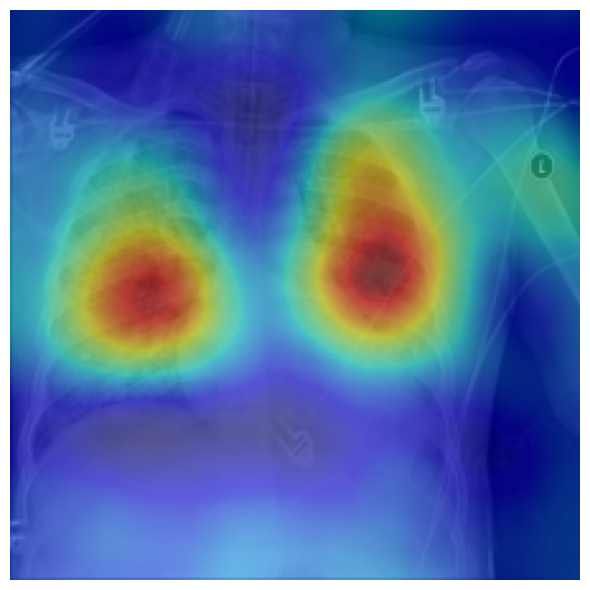

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.29it/s]


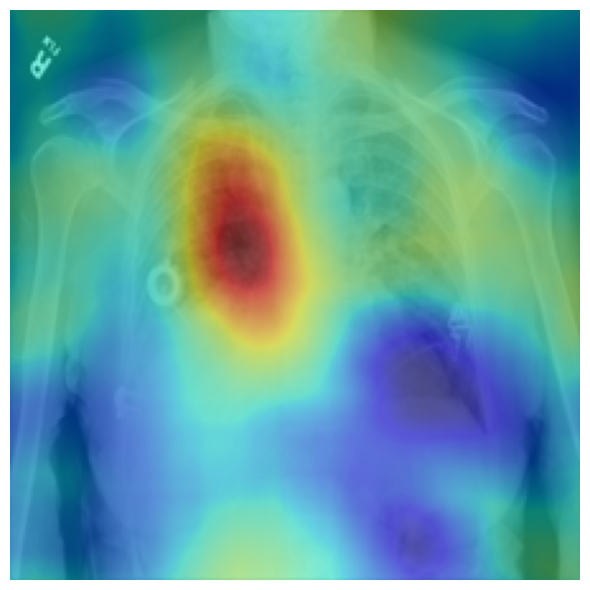

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.22it/s]


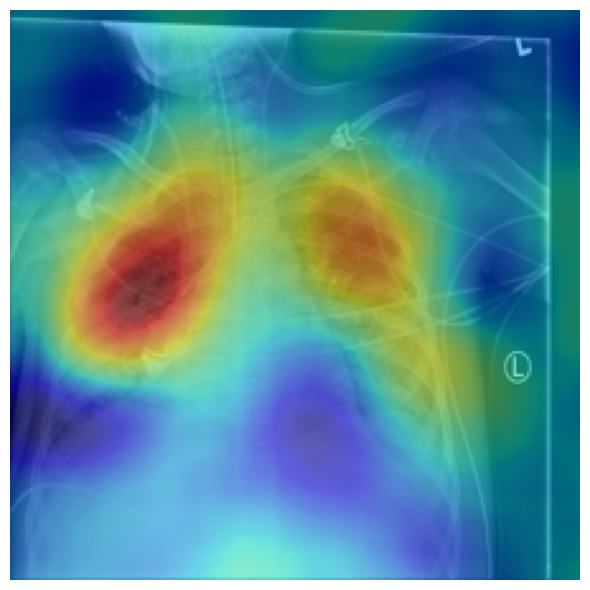

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.13it/s]


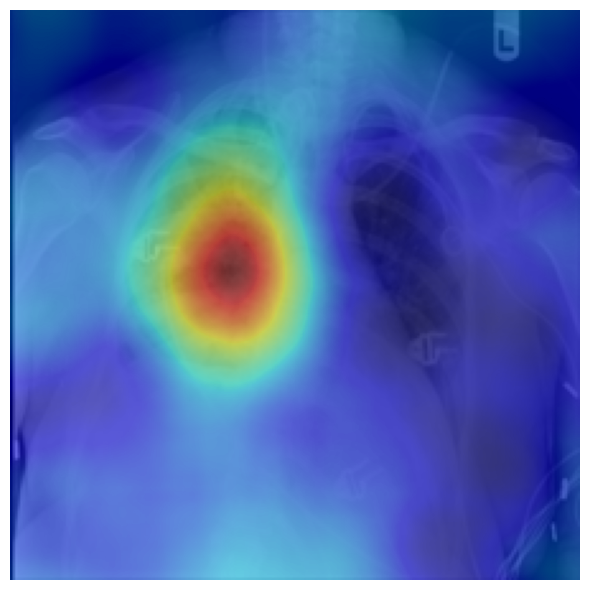

In [19]:
heatmaps_rise = []
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    
    idx = all_labels.index("Infiltration")
    
    print("Gerando mapa de saliência...")
    with torch.no_grad():
        sal = explainer(input_tensor)
        sal_map = sal[idx].cpu().numpy()
        heatmaps_rise.append(sal_map)


    plt.figure(figsize=(6, 6))
    
    # Imagem original
    img_display = np.array(img)
    
    raw_np = np.array(img.resize((224, 224))) / 255.0
    
    # Overlay
    plt.imshow(raw_np)
    plt.imshow(sal_map, cmap='jet', alpha=0.5)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()



In [20]:
broke_list = []
for image_path, heatmap in zip(image_paths, heatmaps_rise):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration', max_steps=1000)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))




Broke at step: 91
Broke at step: 5
Broke at step: 133
Broke at step: 15
Average broke:  61.0


In [21]:
robustness_score_list = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'RISE', input_tensor, explainer)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))

Processing masks: 100%|██████████| 30/30 [00:11<00:00,  2.53it/s]


Robustness score: 0.8974565267562866


Processing masks: 100%|██████████| 30/30 [00:11<00:00,  2.64it/s]


Robustness score: 0.82343590259552


Processing masks: 100%|██████████| 30/30 [00:11<00:00,  2.64it/s]


Robustness score: 0.873451828956604


Processing masks: 100%|██████████| 30/30 [00:11<00:00,  2.62it/s]


Robustness score: 0.906670868396759
Average robustness score:  0.8752538


In [22]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_rise:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.05530649301957111
Spatial Coherence: 0.5757836699485779
Gini Index: 0.017754301732900192
Spatial Coherence: 0.7691013216972351
Gini Index: 0.0254398268096301
Spatial Coherence: 1.0
Gini Index: 0.024322276212731187
Spatial Coherence: 1.0
Average Gini Index:  0.030705724443708143
Average Spatial Coherence:  0.8362213


In [23]:
consistency = intraclass_consistency(heatmaps_rise)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.4345492449799391


In [24]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall

In [25]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

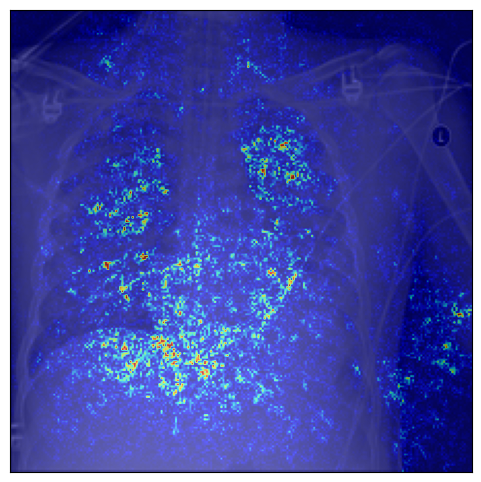

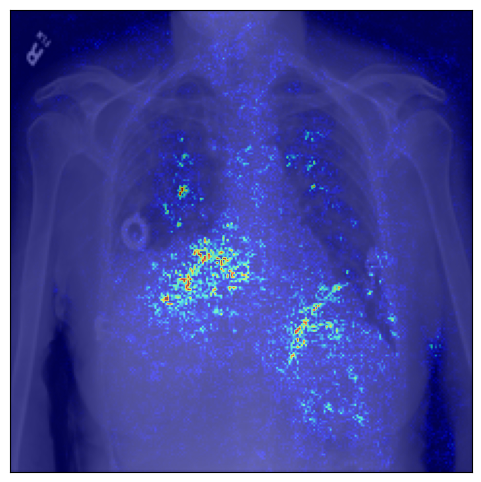

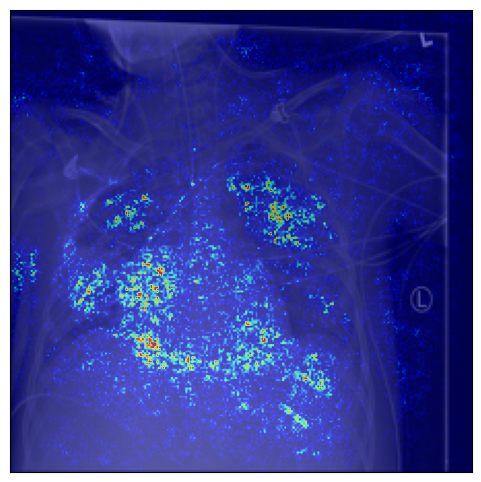

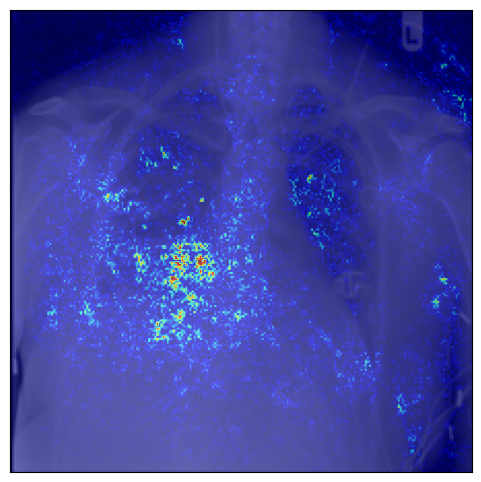

In [ ]:
ig = IntegratedGradients(model)
heatmaps_ig = []
i=1
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    input_tensor.requires_grad_()
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    idx = all_labels.index("Infiltration")
    
    
    baseline = torch.zeros_like(input_tensor).to(device)
    
    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    
    
    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))
    sal_map = np.mean(np.abs(attr_np), axis=2)
    heatmaps_ig.append(sal_map)
    img_np = np.array(img.resize((224, 224))) / 255.0
    
    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="absolute_value", 
        show_colorbar=False,
        use_pyplot=True,
        cmap="jet",            
        outlier_perc=2,        
        alpha_overlay=0.6      
    )

    plt.savefig(f'cub_ig_{i}')
    plt.close()
    i += 1

In [27]:
broke_list = []
for image_path, heatmap in zip(image_paths, heatmaps_ig):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration', max_steps=3000)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))

Broke at step: 92
Broke at step: 3
Broke at step: 220
Broke at step: 9
Average broke:  81.0


In [28]:
robustness_score_list = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'IG', input_tensor, ig.attribute)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))


Robustness score: -0.07452351599931717
Robustness score: -0.07269716262817383
Robustness score: 0.07346825301647186
Robustness score: -0.04935792088508606
Average robustness score:  -0.030777587


In [30]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_ig:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.5564201510682398
Spatial Coherence: 0.0934632420539856
Gini Index: 0.6318047192631936
Spatial Coherence: 0.19970138370990753
Gini Index: 0.5687286221251195
Spatial Coherence: 0.37087482213974
Gini Index: 0.5558983939034599
Spatial Coherence: 0.3891106843948364
Average Gini Index:  0.5782129715900033
Average Spatial Coherence:  0.26328754


In [29]:
consistency = intraclass_consistency(heatmaps_ig)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.23537237270040814


## FUSAO DE METODOS

100%|██████████| 128/128 [00:06<00:00, 20.33it/s]


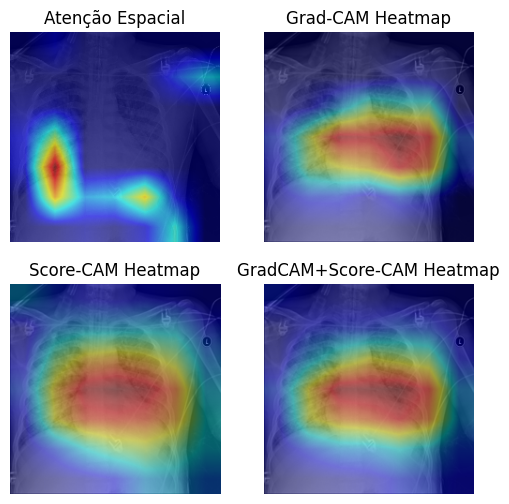

100%|██████████| 128/128 [00:06<00:00, 20.41it/s]


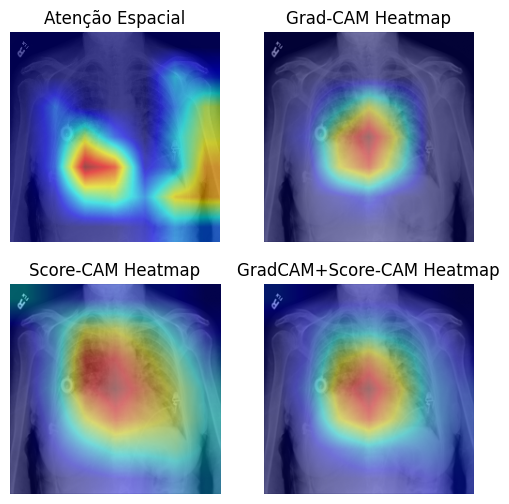

100%|██████████| 128/128 [00:06<00:00, 20.37it/s]


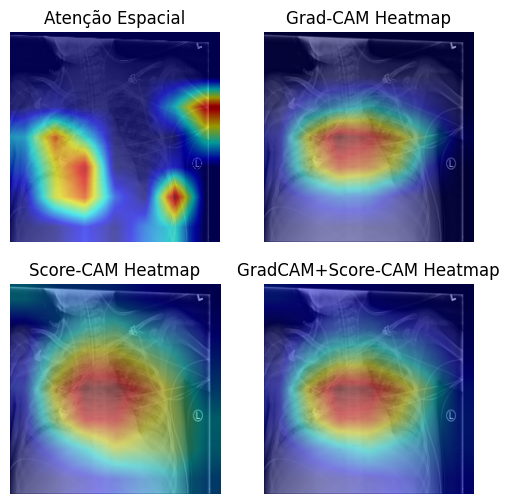

100%|██████████| 128/128 [00:06<00:00, 20.28it/s]


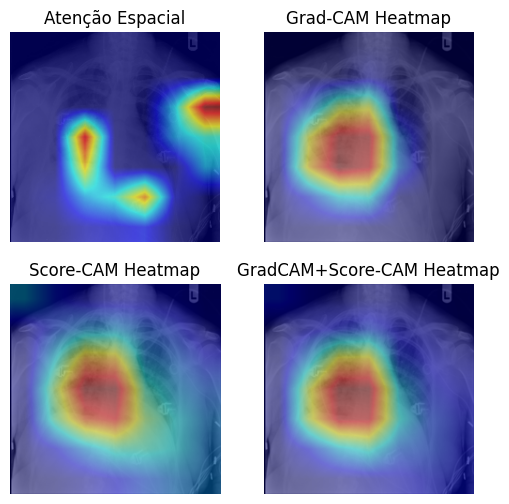

In [16]:
union_heatmaps = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    raw_np = np.array(img.resize((224, 224))) / 255.0

    plt.figure(figsize=(6, 6))

    # ATTENTION MAP
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()


    
    attn_map = activation['spatial_attn'][0, 0].cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    attn_map_resized = cv2.resize(attn_map, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * attn_map_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)


    img_np = np.array(img)
    img_np = cv2.resize(img_np, (224, 224))
    superimposed = np.uint8(0.6 * heatmap + 0.4 * img_np)

    plt.subplot(2, 2, 1)
    plt.title("Atenção Espacial")
    plt.imshow(superimposed, cmap='jet')
    plt.axis('off')

    # GRADCAM
    cam_grad = gradcam.generate(input_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam_grad)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap * 0.4 + raw_np * 0.6
    overlay = np.clip(overlay, 0, 1)
    

    plt.subplot(2, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(overlay, cmap='jet')
    plt.axis('off')

    


    # SCORE CAM
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    target_layer = model.cbam4
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    heatmap_score = cv2.applyColorMap(np.uint8(255 * grayscale_cam), cv2.COLORMAP_JET)
    heatmap_score = cv2.cvtColor(heatmap_score, cv2.COLOR_BGR2RGB)
    heatmap_score = np.float32(heatmap_score) / 255
    # --------------------------

    # Agora a soma funciona porque ambos são (224, 224, 3)
    overlay_score = heatmap_score * 0.4 + raw_np * 0.6 
    overlay_score = np.clip(overlay_score, 0, 1)

    plt.subplot(2, 2, 3)
    plt.title("Score-CAM Heatmap")
    plt.imshow(overlay_score) # Agora vai estar nas cores certas
    plt.axis('off')

    # FUSAO DE MAPAS
    gradcam_normalized = cam_grad  
    
    
    fused_heatmap = gradcam_normalized + grayscale_cam
    
    # Normalizar para [0, 1]
    fused_heatmap = (fused_heatmap - fused_heatmap.min()) / (fused_heatmap.max() - fused_heatmap.min())
    

    fused_heatmap_color = cv2.applyColorMap(np.uint8(255 * fused_heatmap), cv2.COLORMAP_JET)
    fused_heatmap_color = cv2.cvtColor(fused_heatmap_color, cv2.COLOR_BGR2RGB)
    fused_heatmap_color = np.float32(fused_heatmap_color) / 255
    

    fused_overlay = fused_heatmap_color * 0.4 + raw_np * 0.6
    fused_overlay = np.clip(fused_overlay, 0, 1)

    plt.subplot(2, 2, 4)
    plt.title("GradCAM+Score-CAM Heatmap")
    plt.imshow(fused_overlay)
    plt.axis('off')

    union_heatmaps.append(fused_heatmap)

    plt.show()

In [17]:
def get_union_heatmap(input_tensor):
    cam_grad = gradcam.generate(input_tensor)
    heatmap_grad = cv2.applyColorMap(np.uint8(255 * (1 - cam_grad)), cv2.COLORMAP_JET)
    heatmap_grad = np.float32(heatmap) / 255

    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    target_layer = model.cbam4
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    heatmap_score = cv2.applyColorMap(np.uint8(255 * grayscale_cam), cv2.COLORMAP_JET)
    heatmap_score = cv2.cvtColor(heatmap_score, cv2.COLOR_BGR2RGB)
    heatmap_score = np.float32(heatmap_score) / 255
     
    
    fused_heatmap = cam_grad + grayscale_cam  
    # Normalizar para [0, 1]
    fused_heatmap = (fused_heatmap - fused_heatmap.min()) / (fused_heatmap.max() - fused_heatmap.min())


    return fused_heatmap

In [40]:
broke_list = []
for image_path, heatmap in zip(image_paths, union_heatmaps):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]


    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration', max_steps=3000)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))

Broke at step: 32
Broke at step: 1
Broke at step: 114
Broke at step: 11
Average broke:  39.5


In [18]:


robustness_score_list = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'Grad+Score', input_tensor, get_union_heatmap)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))


100%|██████████| 128/128 [00:06<00:00, 19.43it/s]


Robustness score: 0.49269992113113403


100%|██████████| 128/128 [00:06<00:00, 19.05it/s]


Robustness score: 0.457475483417511


100%|██████████| 128/128 [00:06<00:00, 18.77it/s]


Robustness score: 0.8603034019470215


100%|██████████| 128/128 [00:06<00:00, 18.62it/s]

Robustness score: 0.4092186987400055
Average robustness score:  0.55492437


In [20]:
gini_list = []
coherence_list = []
for heatmap in union_heatmaps:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.4653478349958147
Spatial Coherence: 1.0
Gini Index: 0.4880608539192044
Spatial Coherence: 1.0
Gini Index: 0.4568571752431441
Spatial Coherence: 1.0
Gini Index: 0.5298435444734535
Spatial Coherence: 1.0
Average Gini Index:  0.48502735215790416
Average Spatial Coherence:  1.0


In [22]:
consistency = intraclass_consistency(union_heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.8920241403957189
